In [29]:
import sys
import gymnasium as gym
import numpy as np
import torch
from gymnasium.wrappers import TimeLimit
from torch import Tensor, nn, optim
from torch.nn.functional import mse_loss
from tqdm import trange
sys.path.append("..")
from actor import Actor
from fnn import FNN
from utils import device, polyak_update
from config import Config


def add_transition(
  replay_state: Tensor,
  replay_action: Tensor,
  replay_reward: Tensor,
  replay_done: Tensor,
  replay_next_state: Tensor,
  replay_idx: int,
  replay_size: int,
  replay_capacity: int,
  state: Tensor,
  action: Tensor,
  reward: float,
  done: bool,
  next_state: Tensor,
) -> tuple[int, int]:
  replay_state[replay_idx].copy_(state)
  replay_action[replay_idx].copy_(action)
  replay_reward[replay_idx, 0] = float(reward)
  replay_done[replay_idx, 0] = 1.0 if done else 0.0
  replay_next_state[replay_idx].copy_(next_state)
  replay_idx = (replay_idx + 1) % replay_capacity
  replay_size = min(replay_size + 1, replay_capacity)
  return replay_idx, replay_size


def sample_batch(
  replay_state: Tensor,
  replay_action: Tensor,
  replay_reward: Tensor,
  replay_done: Tensor,
  replay_next_state: Tensor,
  replay_size: int,
  batch_size: int,
) -> tuple[Tensor, Tensor, Tensor, Tensor, Tensor]:
  idx = torch.randint(0, replay_size, (batch_size,), device = device)
  return replay_state[idx], replay_action[idx], replay_reward[idx], replay_done[idx], replay_next_state[idx]


rng = np.random.default_rng(0)
env = gym.make("HalfCheetah-v5")
env = TimeLimit(env, max_episode_steps = 500)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_low = torch.tensor(env.action_space.low, dtype = torch.float32, device = device)
action_high = torch.tensor(env.action_space.high, dtype = torch.float32, device = device)

num_episodes = 5000
batch_size = 256
replay_capacity = 100000
gamma = 0.99
actor_lr = 3e-4
critic_lr = 3e-4
actor_polyak = 0.005
critic_polyak = 1
actor_update_interval = 1
update_every_steps = 10
noise_std = 0.05
noise_std_min = 0.0001
noise_std_decay = 0.99995
hidden_size = 256
num_hidden_layers = 3
print_interval = 200

config = Config(
    state_dim = state_dim + action_dim,
    action_dim = 1,
    action_tanh = False,
    num_encoders = 2,
    tree_depth = 2,
    critic_num_hidden_layers = None,
    actor_num_hidden_layers = 4,
    embed_dim = 32,
    discount_rate = None,
    learning_rate = 1,
    critic_polyak_factor = None,
    actor_polyak_factor = None,
    batch_size = None,
    num_episodes = None,
    replay_buffer_size = None,
    add_probability = None,
    critic_update_interval = None,
    actor_update_interval = None,
    noise_std = None,
    noise_std_min = None,
    noise_std_decay = None,
)
# Values with None are not used in this code

actor = FNN(
  input_size = state_dim,
  hidden_size = hidden_size,
  num_hidden_layers = num_hidden_layers,
  output_size = action_dim,
  output_activation = nn.Tanh(),
).to(device)
critic = Actor(
    config = config,
    rng = rng,
).to(device)
actor_target = FNN(
  input_size = state_dim,
  hidden_size = hidden_size,
  num_hidden_layers = num_hidden_layers,
  output_size = action_dim,
  output_activation = nn.Tanh(),
).to(device)
for target_param, param in zip(actor_target.parameters(), actor.parameters()):
  target_param.data.copy_(param.data)
for param in actor_target.parameters():
  param.requires_grad_(False)

actor_optimizer = optim.Adam(actor.parameters(), lr = actor_lr)
critic_optimizer = optim.Adam(critic.parameters(), lr = critic_lr)

replay_state = torch.empty((replay_capacity, state_dim), dtype = torch.float32, device = device)
replay_action = torch.empty((replay_capacity, action_dim), dtype = torch.float32, device = device)
replay_reward = torch.empty((replay_capacity, 1), dtype = torch.float32, device = device)
replay_done = torch.empty((replay_capacity, 1), dtype = torch.float32, device = device)
replay_next_state = torch.empty((replay_capacity, state_dim), dtype = torch.float32, device = device)
replay_idx = 0
replay_size = 0

episode_rewards = []
train_updates = 0
env_steps = 0

for episode in trange(num_episodes):
  state_np, _ = env.reset(seed = episode)
  state = torch.tensor(state_np, dtype = torch.float32, device = device)
  episode_reward = 0.0
  terminated = False
  truncated = False

  while not terminated and not truncated:
    with torch.no_grad():
      action = actor(state.unsqueeze(0))[0]
    action = action + torch.randn_like(action) * noise_std
    action = action.clamp(min = action_low, max = action_high)

    next_state_np, reward, terminated, truncated, _ = env.step(action.cpu().numpy())
    done = bool(terminated or truncated)
    next_state = torch.tensor(next_state_np, dtype = torch.float32, device = device)

    replay_idx, replay_size = add_transition(
      replay_state = replay_state,
      replay_action = replay_action,
      replay_reward = replay_reward,
      replay_done = replay_done,
      replay_next_state = replay_next_state,
      replay_idx = replay_idx,
      replay_size = replay_size,
      replay_capacity = replay_capacity,
      state = state,
      action = action,
      reward = float(reward),
      done = done,
      next_state = next_state,
    )

    state = next_state
    episode_reward += float(reward)
    env_steps += 1

    if replay_size >= batch_size and env_steps % update_every_steps == 0:
      batch_state, batch_action, batch_reward, batch_done, batch_next_state = sample_batch(
        replay_state = replay_state,
        replay_action = replay_action,
        replay_reward = replay_reward,
        replay_done = replay_done,
        replay_next_state = replay_next_state,
        replay_size = replay_size,
        batch_size = batch_size,
      )

      module_idx = rng.integers(0, len(critic._online_models))
      with torch.no_grad():
        next_action = actor_target(batch_next_state)
        next_state_action = torch.cat([batch_next_state, next_action], dim = 1)
        _, next_q = critic(next_state_action, module_idx = -1)
        target_q = batch_reward + (1.0 - batch_done) * gamma * next_q

      state_action = torch.cat([batch_state, batch_action], dim = 1)
      _, q = critic(state_action, module_idx = module_idx)
      critic_loss = mse_loss(q, target_q)
      critic_optimizer.zero_grad(set_to_none = True)
      critic_loss.backward()
      critic_optimizer.step()
      critic_optimizer.zero_grad(set_to_none = True)
      polyak_update(critic._target_models[module_idx], critic._online_models[module_idx], critic_polyak)

      actor_loss = torch.tensor(float("nan"), device = device)
      if train_updates % actor_update_interval == 0:
        actor_action = actor(batch_state)
        actor_state_action = torch.cat([batch_state, actor_action], dim = 1)
        _, actor_q = critic(actor_state_action, module_idx = -1)
        actor_loss = -actor_q.mean()
        actor_optimizer.zero_grad(set_to_none = True)
        actor_loss.backward()
        actor_optimizer.step()
        actor_optimizer.zero_grad(set_to_none = True)
        polyak_update(actor_target, actor, actor_polyak)

      train_updates += 1
      if train_updates % print_interval == 0:
        print(f"{train_updates}, cl: {critic_loss.item():.6f}, al: {actor_loss.item():.6f}, tq: {target_q.mean().item():.6f}, ns: {noise_std:.6f}, re: {episode_reward:.6f}")

      noise_std = max(noise_std_min, noise_std * noise_std_decay)

  episode_rewards.append(episode_reward)

print("training_done", len(episode_rewards), episode_rewards[-1])
env.close()

  0%|          | 4/5000 [00:11<4:10:48,  3.01s/it]

200, cl: 0.199056, al: 1.364321, tq: -1.714035, ns: 0.049505, re: -120.226488


  0%|          | 8/5000 [00:22<3:52:12,  2.79s/it]

400, cl: 0.229950, al: 1.762915, tq: -2.197329, ns: 0.049012, re: -134.459350


  0%|          | 12/5000 [00:34<4:09:36,  3.00s/it]

...

20600, cl: 4.212212, al: 5.886416, tq: -6.161443, ns: 0.017851, re: -90.447466


  8%|▊         | 416/5000 [44:15<19:41:31, 15.46s/it]

20800, cl: 2.189548, al: 4.598336, tq: -4.993903, ns: 0.017673, re: -98.020454


  8%|▊         | 416/5000 [44:31<8:10:35,  6.42s/it] 


KeyboardInterrupt: 

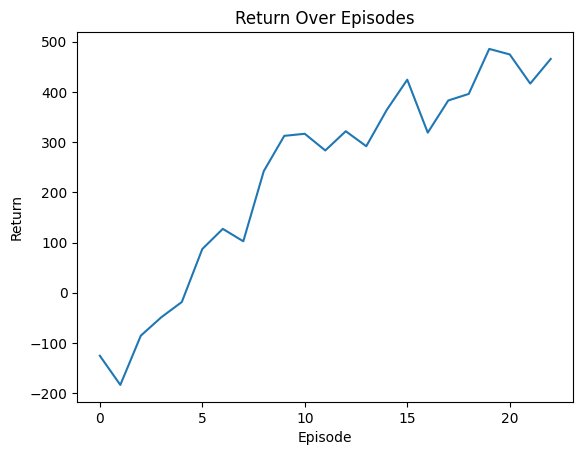

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Return Over Episodes")
plt.show()